# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [38]:
import numpy as np
import os
import sklearn
import pandas as pd
from sklearn import linear_model, metrics
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn import metrics
import numpy as np

In [16]:
temps = pd.read_csv("./data/temps.csv")

### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [17]:
temps.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


In [18]:
temps.info()
# No hay nulos
#columna week en type str.

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 24.6 KB


In [19]:
temps.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


In [20]:
temps['year'].unique()

array([2016])

In [21]:
temps['actual'].value_counts()

actual
57    16
60    16
68    16
65    13
55    12
71    12
52    11
59    11
64    11
67    11
51    10
77    10
49     9
63     9
76     9
66     9
75     9
48     8
54     8
53     8
61     8
73     8
56     7
58     7
74     7
40     6
62     6
81     6
79     6
69     5
80     5
72     5
45     4
44     4
50     4
46     4
85     4
70     4
41     3
82     3
42     3
39     3
47     2
87     2
78     2
83     2
35     2
89     1
92     1
86     1
88     1
90     1
84     1
36     1
43     1
Name: count, dtype: int64

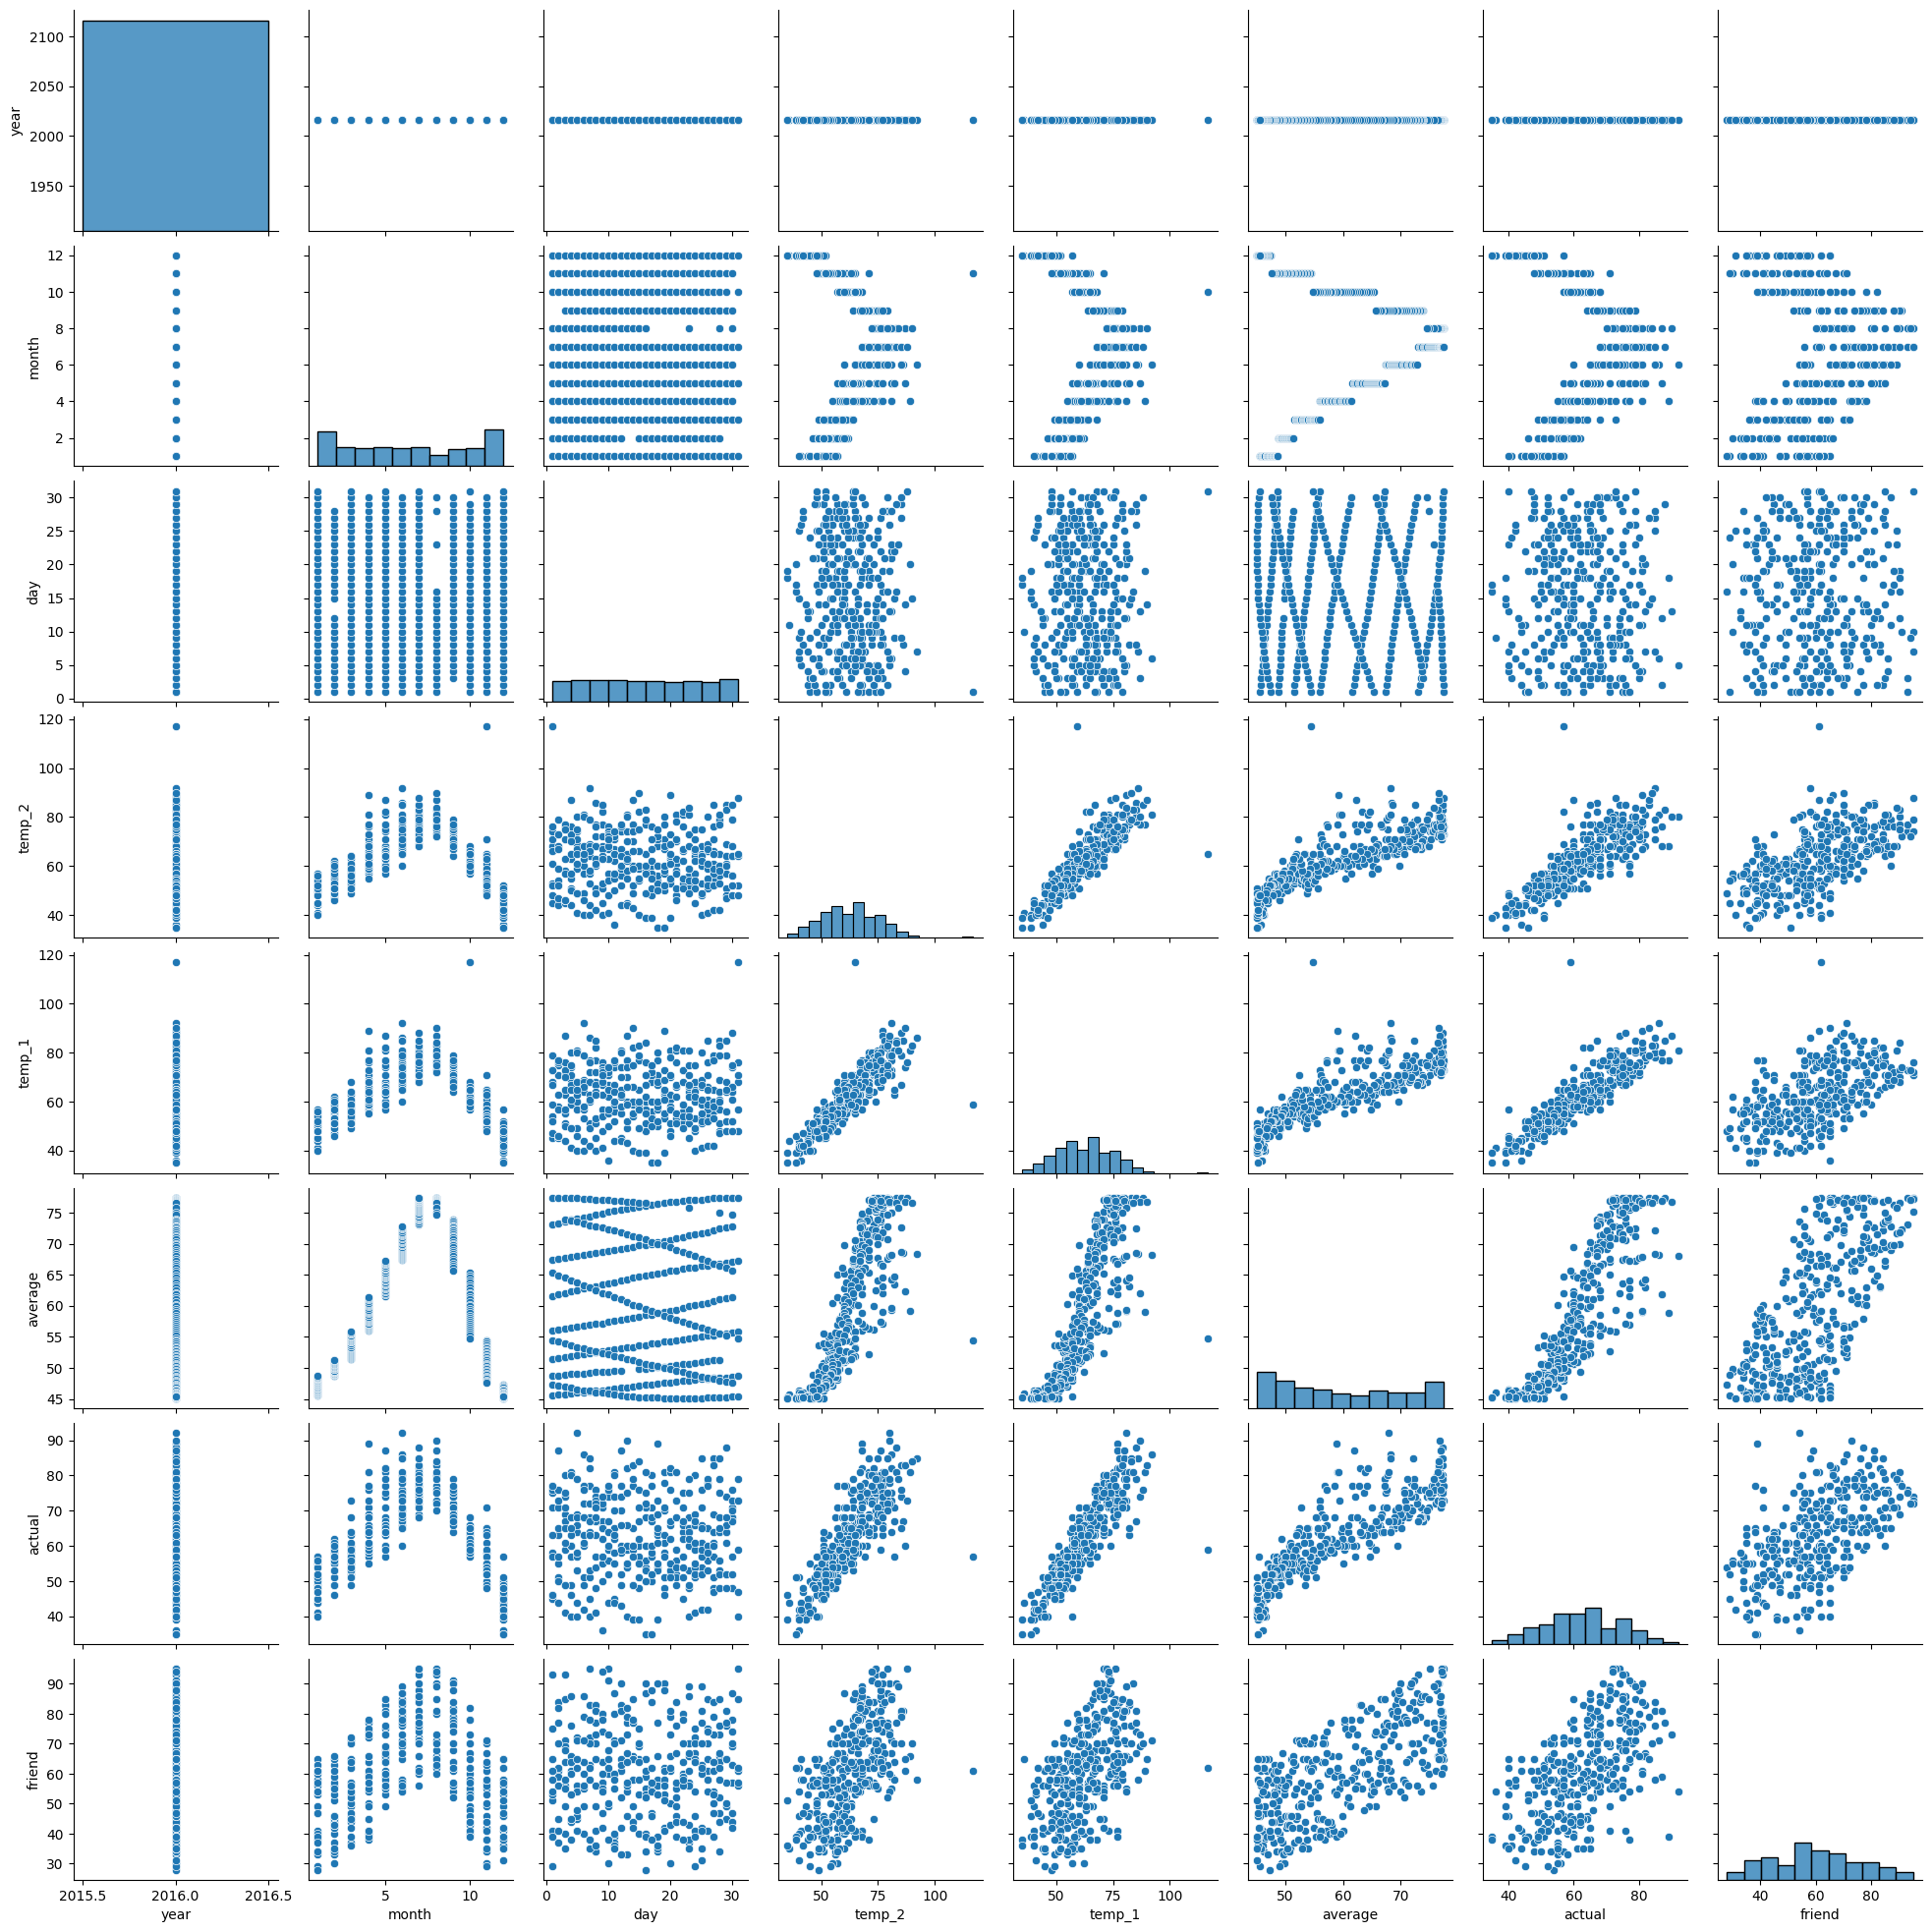

In [22]:
#me hago un pair plot
sns.pairplot(temps)
plt.show()


<Axes: >

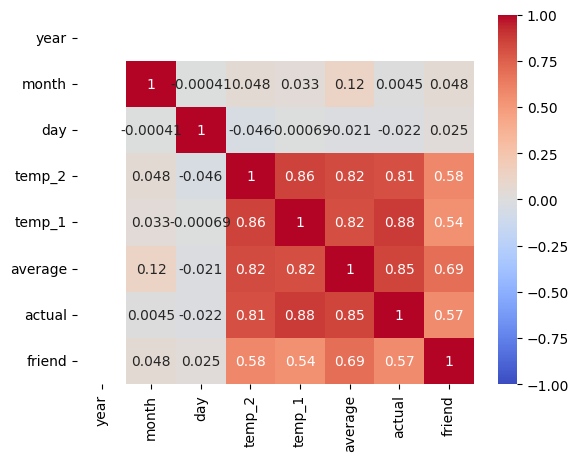

In [23]:
# ver correlaciones.
sns.heatmap(temps.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)
# las features que tiene correlación con mi target (actual) son: 
# temp_2, temp_1, average, y la del amigo (friend) pero no voy a tener en cuenta en mi modelo las predicciones del amigo.

In [24]:
# Elimiar columnas de innecesarias['day', 'year']
temps = temps.drop(columns=['day', 'year'])
temps.head()

,month,week,temp_2,temp_1,average,actual,friend
0,1,Fri,45,45,45.6,45,29
1,1,Sat,44,45,45.7,44,61
2,1,Sun,45,44,45.8,41,56
3,1,Mon,44,41,45.9,40,53
4,1,Tues,41,40,46.0,44,41


In [25]:
temps['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

### 3. Selecciona variables y divide en train y test

In [27]:
from sklearn.model_selection import train_test_split
X = temps[['month','temp_2', 'temp_1', 'average']]
y = temps['actual']

# Me hago la separación entre test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42)


### 4. Entrena el modelo


In [28]:
# from sklearn.tree import DecisionTreeClassifier
#Crear modelo de árbol de decisión
tree = DecisionTreeClassifier(max_depth= 2, #profuncidad del arbol(4 nodos) 
                              random_state= 42)
#Entrenar modelo
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [29]:
from sklearn import metrics  # Importa el módulo completo


In [30]:
# 1. Realizar las predicciones
# Generamos predicciones usando X_test (datos que el modelo no ha visto)
# Esto simula cómo funcionará el modelo en producción
# Luego compararemos y_pred con y_test para medir rendimiento
y_pred = tree.predict(X_test)

#2.Calculo el coeficiente de determinación(R²)[cuánto entiende el modelo de los datos varia entre0–1, cuanto más alto mejor]
r2_score = metrics.r2_score(y_test, y_pred)

# 3. Cálculo de métricas de error: MAE, MAPE, MSE y RMSE
mae = metrics.mean_absolute_error(y_test, y_pred)
mape= metrics.mean_absolute_percentage_error(y_test, y_pred)
mse= metrics.mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)

#4. printeo los resultados
print("r2_score:", r2_score)
print("mae():", mae)
print("mape:", mape)
print("mse:", mse)
print("rmse:", rmse)
# r2. mi modelo acierta sólo el 42% de los datos, es menos de la mitad, con lo cual es un modelo débil
# MAE mi modelo se equivoca de media 6.49 unidades de temperatura
#MAPE el error porcentual medio es del 10%
#MSE 81.42 error global muy alto
#RMSE= 9.02, Hay algunos errores bastante grandes que afectan al modelo

#Conclusion: mi modelono tiene un rendimiento moderado, predice razonablemene bien, pero aún no captura bien la mayoría de los aptrones que hay en los datos.

r2_score: 0.41764067115817993
mae(): 6.485714285714286
mape: 0.10309610068373004
mse: 81.42857142857143
rmse: 9.023778112773575


### 6. Representa el árbol de decisión

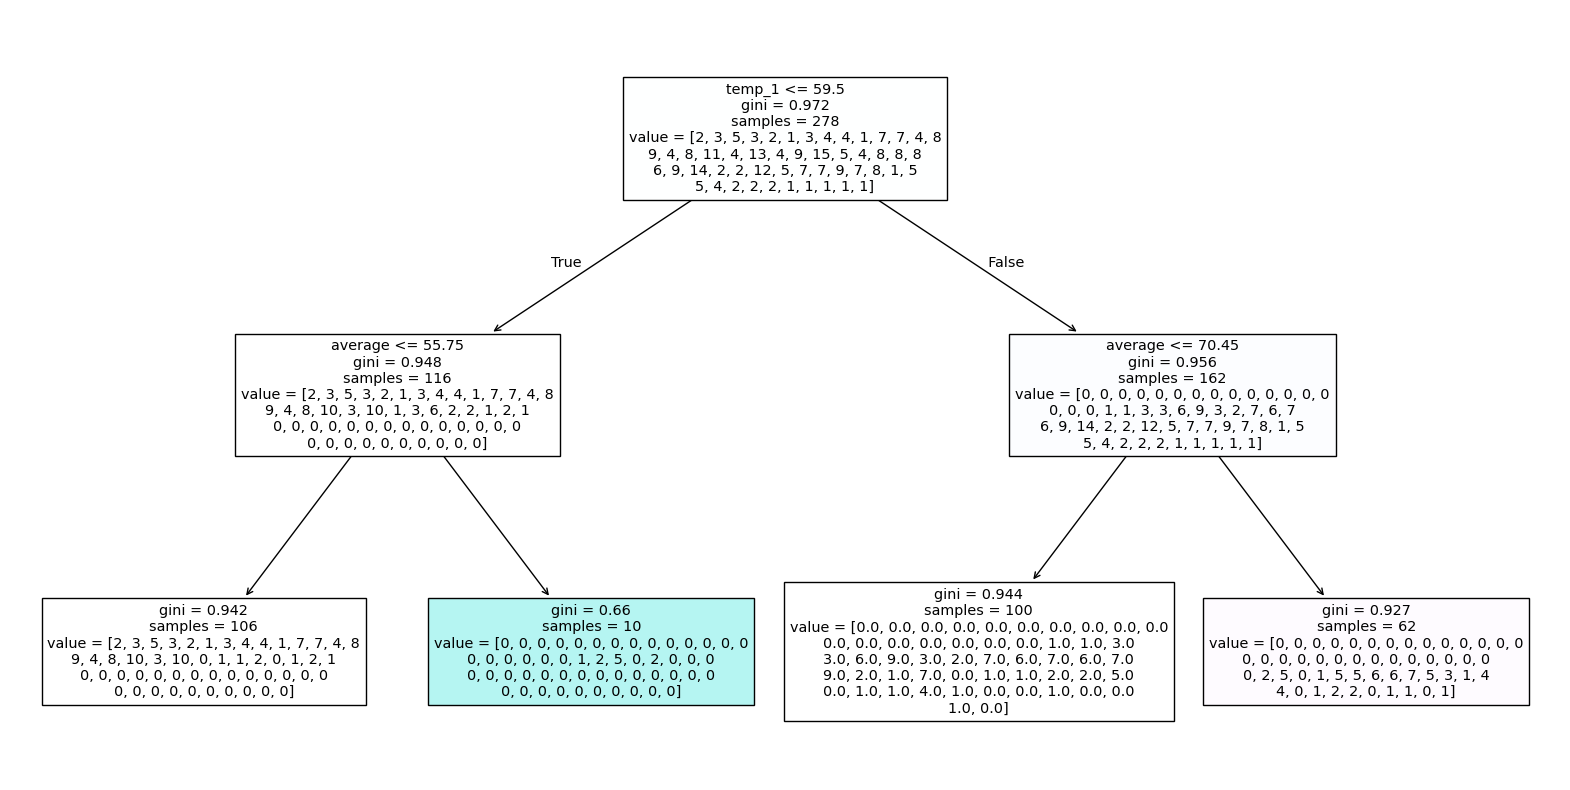

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
sklearn.tree.plot_tree(tree,
               feature_names=['month','temp_2', 'temp_1', 'average'],
                class_names=None,
               filled = True);


### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [32]:
# from sklearn.tree import DecisionTreeClassifier
#Crear modelo de árbol de decisión
tree_2 = DecisionTreeClassifier(max_depth= 3, #profuncidad del arbol(6 nodos) 
                              random_state= 42)
#Entrenar modelo
tree_2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### 8. Vuelve a evaluar tu modelo

In [33]:
# 1. Realizar las predicciones
# Generamos predicciones usando X_test (datos que el modelo no ha visto)
# Esto simula cómo funcionará el modelo en producción
# Luego compararemos y_pred con y_test para medir rendimiento
y_pred = tree_2.predict(X_test)

#2.Calculo el coeficiente de determinación(R²)[cuánto entiende el modelo de los datos varia entre0–1, cuanto más alto mejor]
r2_score = metrics.r2_score(y_test, y_pred)

# 3. Cálculo de métricas de error: MAE, MAPE, MSE y RMSE
mae = metrics.mean_absolute_error(y_test, y_pred)
mape= metrics.mean_absolute_percentage_error(y_test, y_pred)
mse= metrics.mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)

#4. printeo los resultados
print("r2_score:", r2_score)
print("mae():", mae)
print("mape:", mape)
print("mse:", mse)
print("rmse:", rmse)
# Este modelo explica el 57% de la variabilidad de los datos, mejora un poco respecto al modelo anterior.
#MAE:falla de promedio 5.58 unidades de temperatura, el erro es menor respecto al modelo anterior.
#MAPE: tiene un error porcentual de 8.4% que es menor al 10% que daba en el modelo anterior.
#RMSE (7.74) esto nos indica que tiene algunos errores grandes, hay outliers.

#Conclusion: mi modelo presenta alguna mejora respecto al primero, pero sigue teniedo 43% de los datos que no logra explicar.

r2_score: 0.5707909578132481
mae(): 5.585714285714285
mape: 0.08458094545670991
mse: 60.01428571428571
rmse: 7.746888776424101


### 9. Vuelve a representar su árbol

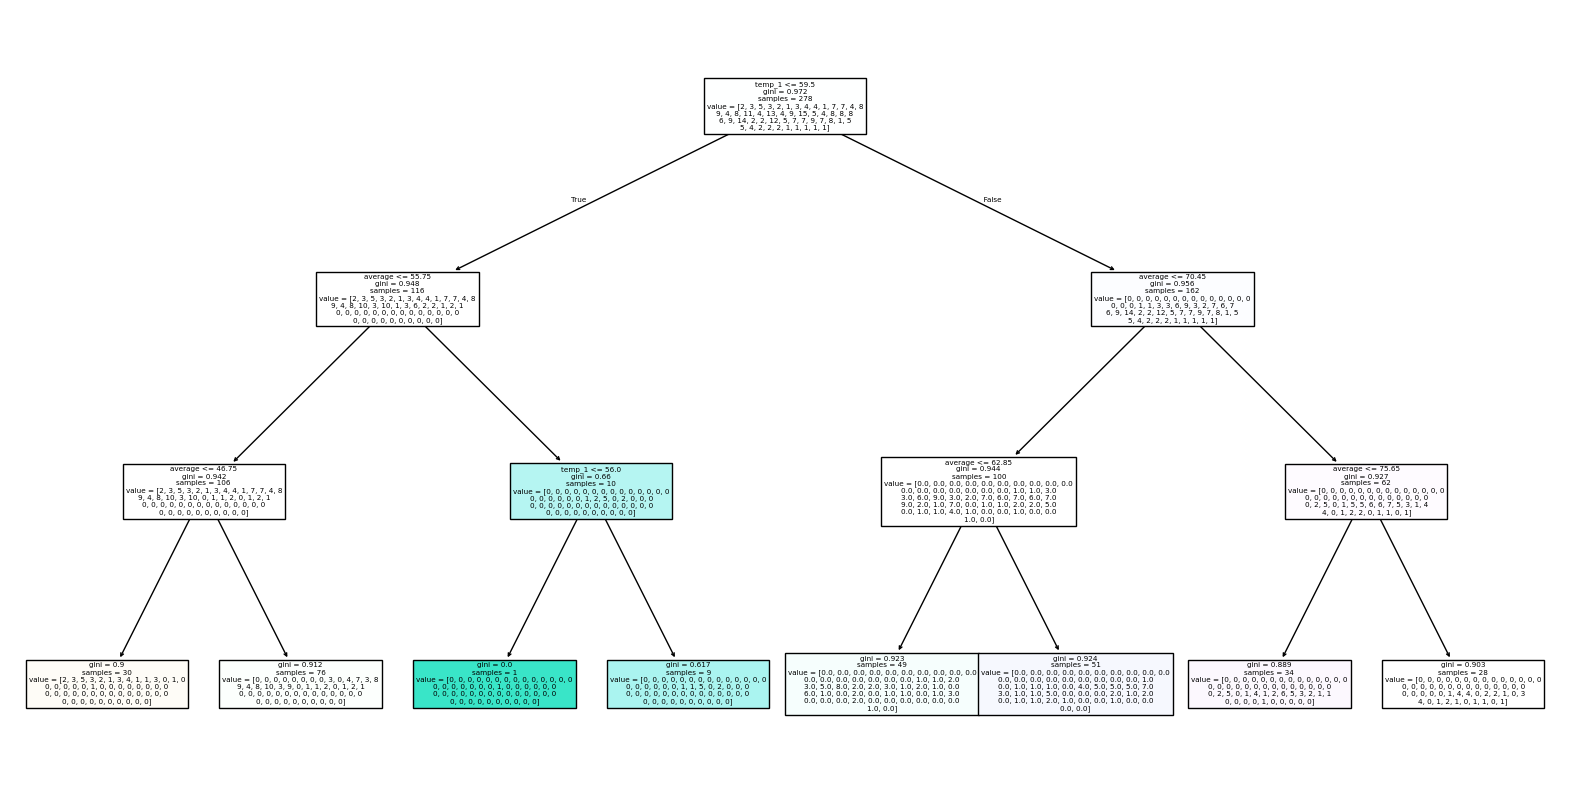

In [34]:

plt.figure(figsize=(20,10))
sklearn.tree.plot_tree(tree_2,
               feature_names=['month','temp_2', 'temp_1', 'average'],
                class_names=None,
               filled = True);

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [35]:
# from sklearn.model_selection import GridSearchCV
#GridSearch es una forma de encontrar automáticamente los mejores parametros del modelo que le pasemos( prueba muchas combinaciones y elige la mejor)
#1. Definir parámetros
params_grid = {
    "max_depth": [3, 5, 10, None], #Profundidad máxima del árbol, None= sin límite
    "min_samples_split": [2, 5, 10], #Mínimo número de muestras para dividir un nodo
    "min_samples_leaf":[2, 4] # Mínimo número de muestras en una hoja
}
#defino mi modelo
model_grid= DecisionTreeRegressor(random_state=42)
#2. 
grid = GridSearchCV(
    estimator=model_grid, # el modelo
    param_grid= params_grid,    # las combinaciones a probar
    cv=5,  # cross validation (5 particiones)
    scoring="r2",# métrica para evaluar (r2 para regresión)
    )
#3.#entreno mi modelo
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 4], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [36]:
#Ver mejores parámetros
print(grid.best_params_)
#me saco tambien el r2
print(grid.best_score_)
# r2 :El modelo explica aproximadamente 77.65% de la variabilidad de los datos. PRESENTA UNA MEJORA RESPECTO AL ANTERIOR.
#REALIZAR PREDICCIONES
y_pred = grid.predict(X_test)

{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.7765634576900615


In [ ]:
# Seleccionamos el mejor modelo
best_model = grid.best_estimator_
#REALIZAR PREDICCIONES
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

#ver métricas mediante función:
def evaluar_modelo(y_test, y_pred):
    print("R2:", r2)
    print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
    print("MSE:", metrics.mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
evaluar_modelo(y_test, y_pred)

#Conclusión: mi mi modelo predice o acierta el 77,86% de lso datos, con lo cual mejora bastante respecto al anterior
# presenta un MAE:4.26 unidades de temperadura, antes tenía casi un 6 con lo cual ha mejorado bastante.
# MSE: 30.94, ha bajado mucho repecto a 60.01 que tenia en el modelo anterior
#rmse: tambien mejora 5.56 frente a 7.74 que tenia en el modelo anterior.

R2: 0.7786776796296856
MAE: 4.267242249556827
MSE: 30.946461197509944
RMSE: 5.5629543587476915


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [44]:
importances = best_model.feature_importances_
importances

array([0.        , 0.        , 0.88110924, 0.11889076])

In [ ]:
# Convertir a DataFrame para verlo mejor
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})
feature_importances

,feature,importance
0,month,0.000000
1,temp_2,0.000000
2,temp_1,0.881109
3,average,0.118891


### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [ ]:
# from sklearn.tree import DecisionTreeClassifier

temps.head()

,month,week,temp_2,temp_1,average,actual,friend
0,1,Fri,45,45,45.6,45,29
1,1,Sat,44,45,45.7,44,61
2,1,Sun,45,44,45.8,41,56
3,1,Mon,44,41,45.9,40,53
4,1,Tues,41,40,46.0,44,41


: 